# Autoencoder on MNIST

This tutorial shows how to use Keras and TensorFlow to build and train a simple shallow AutoEncoder (AE) to generate samples from the MNIST dataset.

references:  
https://keras.io/examples/vision/mnist_convnet \
https://colab.research.google.com/github/trekhleb/machine-learning-experiments/blob/master/experiments/digits_recognition_mlp/digits_recognition_mlp.ipynb \
https://blog.keras.io/building-autoencoders-in-keras.html \
https://keras.io/api/layers/regularizers

aug 2022, hdaniel@ualg.pt \
Update March 10, 2025, jvo@ualg.pt \
sept 2025, autoencoder version, hdaniel@ualg.pt


## Step 1: Load the MNIST dataset and normalize

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from typing import Tuple

2025-09-07 02:51:29.950575: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-07 02:51:31.164484: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# the data, split between train and test sets
# Note that the targets are not needed to train the auto encoder
(xTrain, yTrain), (xTest, _) = keras.datasets.mnist.load_data()

# Join train and test datasets
xTrain = np.concatenate([xTrain, xTest])

# Scale images to the [0, 1] range
xTrain = xTrain.astype("float32") / 255

# Make sure images have shape (28, 28, 1)
xTrain = np.expand_dims(xTrain, -1)

#Display layout
print("xTrain shape:", xTrain.shape)
print(xTrain.shape[0], "train samples")

xTrain shape: (70000, 28, 28, 1)
70000 train samples


### Let's see part of the MNIST data set

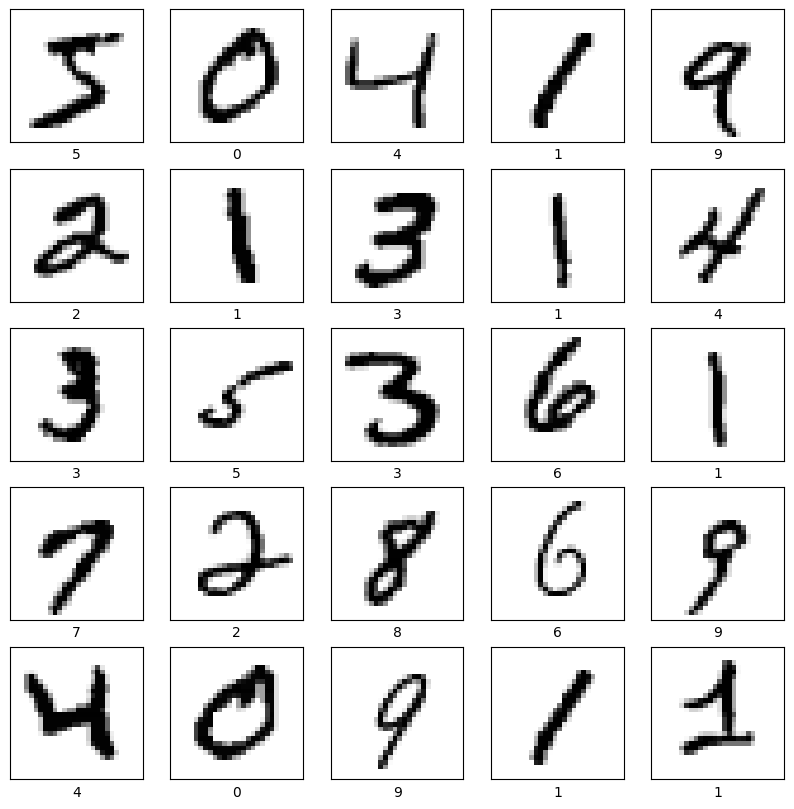

In [3]:
numbers_to_display = 25
num_cells = math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize=(10,10))
for i in range(numbers_to_display):
    plt.subplot(num_cells, num_cells, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(xTrain[i], cmap=plt.cm.binary)
    plt.xlabel(yTrain[i])
plt.show()

#
## Step 2: Create the AutoEncoder model

### Step 2.1: Define the AutoEncoder class

Class AutoEncoderMLP is a subclass of Keras.Model that defines an autoencoder with Dense layers, essentially 2 multi-layer perceptrons in a pipeline. 

The method **_createEncoder()** defines the layers of the encoder, while the method **_createDecoder()** defines the layers of the encoder. These 2 methods accept a parameter named neurons that defines the number of neurons in the sole hidden layer. To add more layers, these parameter must be replaced by a list of integers: ```List[int]```. 

The **call()** method joins the encoder and the decoder to form the autoencoder when calling the **fit()** and **predict()** methods.

In [4]:
class AutoEncoderMLP(keras.Model):

    def __init__(self, inputShape:Tuple[int,int], encoderNeurons:int, decoderNeurons:int, 
                 liReg:float, numLatentFeatures:int, **kwargs):
        super().__init__(**kwargs)
        self._encoder = self._createEncoder(inputShape, encoderNeurons, numLatentFeatures, l1Reg)
        self._decoder = self._createDecoder(inputShape, decoderNeurons, numLatentFeatures, l1Reg)
        
        # full autoencoder is accessed by methods fit() and predict() 
        # because it is defined in method: call(self)

    def encoder(self):     return self._encoder
    def decoder(self):     return self._decoder
    
    def _createEncoder(self, inputShape:Tuple[int,int], neurons:int, numlatentFeatures:int, l1Reg:int):
        '''Define the encoder'''
        encoderInput = layers.Input(shape=inputShape)
        flat = layers.Flatten()(encoderInput)
        h = layers.Dense(neurons, activation ='relu', activity_regularizer=keras.regularizers.l1(l1Reg))(flat)
        encoderOutput = keras.layers.Dense(numlatentFeatures, activation='relu')(h)
        return keras.Model(inputs=encoderInput, outputs=encoderOutput, name="MLPencoder")

    
    def _createDecoder(self, inputShape:Tuple[int,int], neurons:int, numlatentFeatures:int, l1Reg:int):
        '''Define the decoder'''
        decoderInput = keras.Input(shape=(numlatentFeatures,))
        h = layers.Dense(neurons, activation ='relu', activity_regularizer=keras.regularizers.l1(l1Reg))(decoderInput)
        flat = keras.layers.Dense(inputShape[0]*inputShape[1], activation='sigmoid')(h)
        decoderOutput = layers.Reshape(inputShape)(flat)
        return keras.Model(inputs=decoderInput, outputs=decoderOutput, name="MPLdecoder")

    
    #Subclasses of keras.model 
    #need to define forward pass to fit, predict, ... methods
    #
    #optionally can have a boolean argument: training
    #which can be used to specify a different behavior in training and inference,
    #see examples in:
    #https://keras.io/api/models/model/
    def call(self, data, training=False):
        encoderOutput = self._encoder(data)
        return self._decoder(encoderOutput)


### Step 2.2: Define the AutoEncoder

In [5]:
digitShape = xTrain[0].shape
neurons = 128
numLatentFeatures = 2
l1Reg = 10e-5

ae = AutoEncoderMLP((28,28), neurons, neurons, l1Reg, numLatentFeatures)

2025-09-07 02:51:34.487907: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-07 02:51:34.625832: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-07 02:51:34.626493: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

### Step 2.3: The encoder architecture

In [6]:
encoder = ae.encoder()
encoder.summary()

Model: "MLPencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,738 (393.51 KB)

 Trainable params: 100,738 (393.51 KB)

 Non-trainable params: 0 (0.00 B)

###
### Step 2.3: The decoder architecture

In [ ]:
decoder = ae.decoder()
decoder.summary()

Model: "MPLdecoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,520 (396.56 KB)

 Trainable params: 101,520 (396.56 KB)

 Non-trainable params: 0 (0.00 B)

#
## Step 3: Train the  model on the MNIST dataset

In [8]:
batchSize = 128
epochs    = 20

# Set optimiser to Adam and loss to Mean Squared Error
ae.compile(optimizer='adam', loss='mse')

# Fit(X,y), both X and y are the same xTrain, since it is an autoencoder
# it is intendent to learn how to encode and decode xTrain digits
trainingHistory = ae.fit(xTrain, xTrain, batch_size=batchSize, epochs=epochs, shuffle=True, validation_split=0.1)

Epoch 1/20


I0000 00:00:1757209897.753485  279004 service.cc:145] XLA service 0x7a120c0064b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757209897.753546  279004 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 965M, Compute Capability 5.2
2025-09-07 02:51:37.794545: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-07 02:51:37.997877: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 60/493 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2946

I0000 00:00:1757209899.120555  279004 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.2238 - val_loss: 0.1614
Epoch 2/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1488 - val_loss: 0.1225
Epoch 3/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1148 - val_loss: 0.1013
Epoch 4/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0963 - val_loss: 0.0895
Epoch 5/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0857 - val_loss: 0.0826
Epoch 6/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0795 - val_loss: 0.0783
Epoch 7/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0757 - val_loss: 0.0755
Epoch 8/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0732 - val_loss: 0.0736
Epoch 9/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0716 - val_loss: 0.0723
Epoch 10/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0702 - val_loss: 0.0714
Epoch 11/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0694 - val_loss: 0.0708
Epoch 12/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.

## Step 4: Evaluate the model on the MNIST dataset

### Loss function evolution during the training

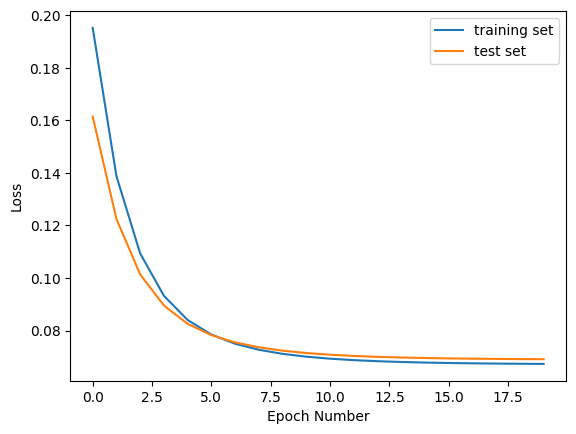

In [9]:
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.plot(trainingHistory.history['loss'], label='training set')
plt.plot(trainingHistory.history['val_loss'], label='test set')
plt.legend()

## Step 5: Synthesize new images from the learned latent space

In [10]:
numGenerate = 100
    
# Sample white noise random vectors from a normal distribution
zSample = np.random.normal(size=(numGenerate, numLatentFeatures))
    
# Decode the random noisy vectors into images
generated = ae.decoder().predict(zSample)        

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step


## Step 6: Plot the synthesized images

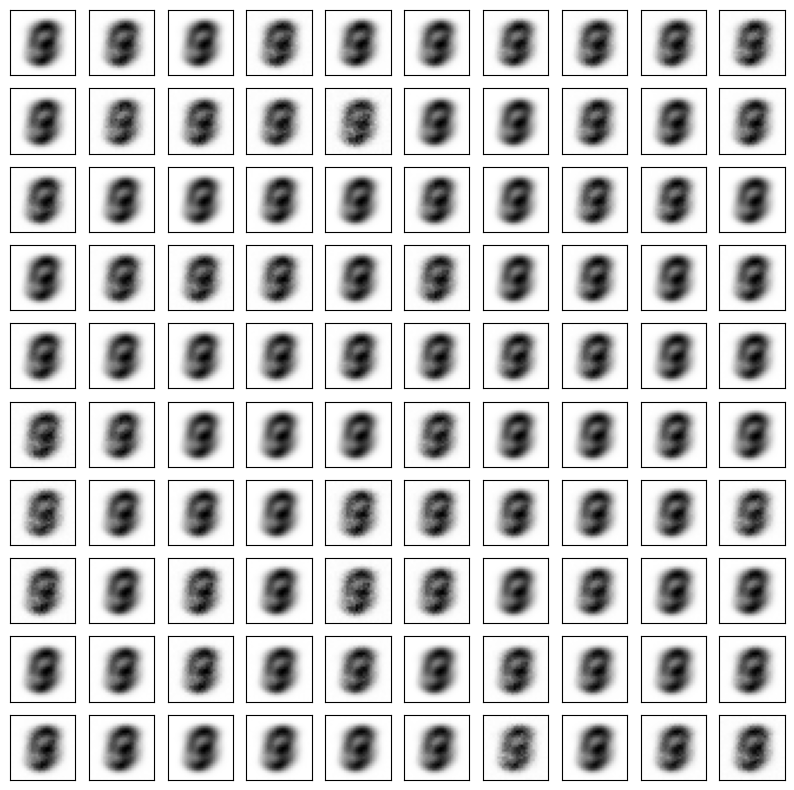

In [11]:
plt.figure(figsize=(10,10))
for i in range(numGenerate):
    plt.subplot(10, 10, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(generated[i], cmap=plt.cm.binary)
plt.show()